Saving Screenshot 2024-12-05 at 4.21.12 PM.png to Screenshot 2024-12-05 at 4.21.12 PM (2).png


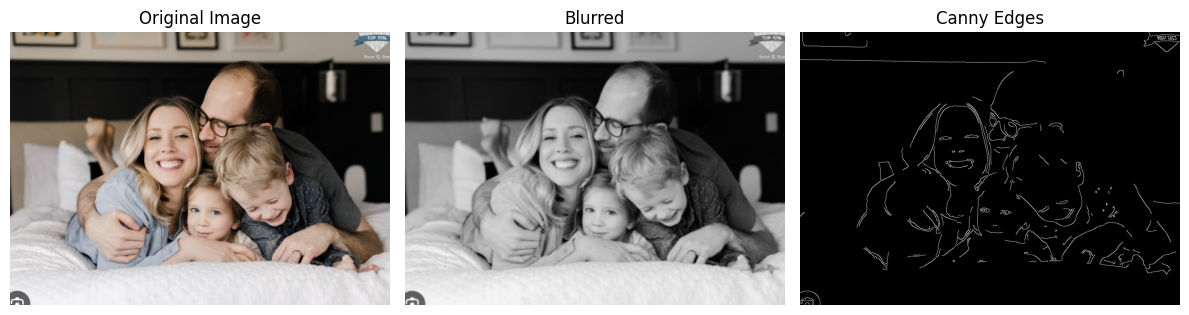

In [ ]:
import cv2
import numpy as np
from google.colab import files
from IPython.display import Image, display
import matplotlib.pyplot as plt

def upload_and_detect_edges(low_threshold=100, high_threshold=200):
    uploaded = files.upload()

    file_name = next(iter(uploaded))

    img = cv2.imread(file_name)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blurred, low_threshold, high_threshold)

    plt.figure(figsize=(12, 4))

    plt.subplot(131)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(132)
    plt.imshow(blurred, cmap='gray')
    plt.title('Blurred')
    plt.axis('off')

    plt.subplot(133)
    plt.imshow(edges, cmap='gray')
    plt.title('Canny Edges')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return edges

edges = upload_and_detect_edges()

Upload first image:


Saving Screenshot 2024-12-05 at 4.21.12 PM.png to Screenshot 2024-12-05 at 4.21.12 PM (3).png
Upload second image:


Saving Screenshot 2024-12-05 at 4.29.17 PM.png to Screenshot 2024-12-05 at 4.29.17 PM.png


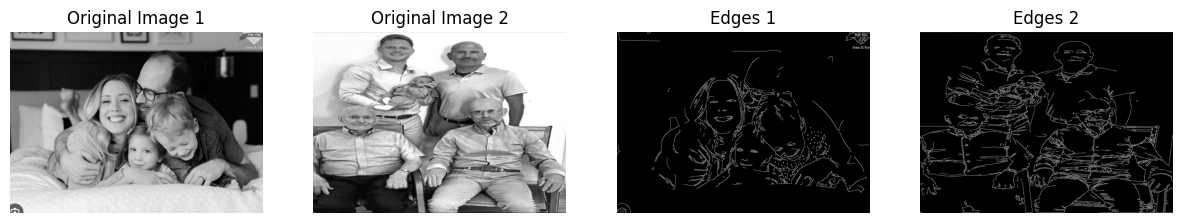

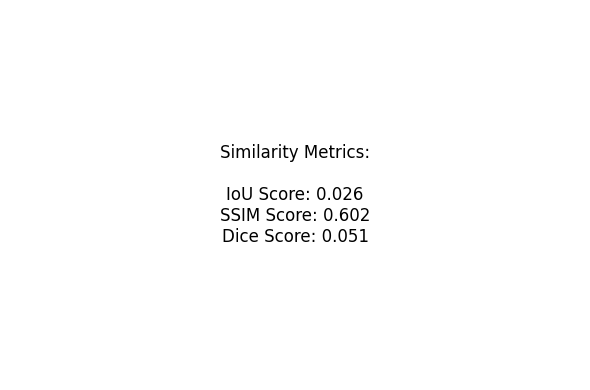

In [ ]:

!pip install scikit-image

import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.spatial.distance import dice
from google.colab import files
import matplotlib.pyplot as plt

def compare_edges(edges1, edges2, method='all'):
    """
    Compare two Canny edge outputs using multiple similarity metrics.
    """
    if edges1.shape != edges2.shape:
        raise ValueError("Images must be the same size")

    edges1_bin = edges1.astype(bool)
    edges2_bin = edges2.astype(bool)

    metrics = {}

    if method in ['iou', 'all']:
        intersection = np.logical_and(edges1_bin, edges2_bin).sum()
        union = np.logical_or(edges1_bin, edges2_bin).sum()
        iou_score = intersection / union if union != 0 else 0
        if method == 'iou':
            return iou_score
        metrics['iou'] = iou_score

    if method in ['ssim', 'all']:
        ssim_score = ssim(edges1, edges2, data_range=edges1.max() - edges1.min())
        if method == 'ssim':
            return ssim_score
        metrics['ssim'] = ssim_score

    if method in ['dice', 'all']:
        dice_score = 1 - dice(edges1_bin.flatten(), edges2_bin.flatten())
        if method == 'dice':
            return dice_score
        metrics['dice'] = dice_score

    return metrics

def compare_uploaded_edges():
    """
    Function to handle image uploads and comparison
    """
    print("Upload first image:")
    uploaded1 = files.upload()
    file1 = next(iter(uploaded1))

    print("Upload second image:")
    uploaded2 = files.upload()
    file2 = next(iter(uploaded2))

    img1 = cv2.imread(file1, 0)
    img2 = cv2.imread(file2, 0)

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    edges1 = cv2.Canny(img1, 100, 200)
    edges2 = cv2.Canny(img2, 100, 200)

    similarity = compare_edges(edges1, edges2)

    plt.figure(figsize=(15, 5))

    plt.subplot(141)
    plt.imshow(img1, cmap='gray')
    plt.title('Original Image 1')
    plt.axis('off')

    plt.subplot(142)
    plt.imshow(img2, cmap='gray')
    plt.title('Original Image 2')
    plt.axis('off')

    plt.subplot(143)
    plt.imshow(edges1, cmap='gray')
    plt.title('Edges 1')
    plt.axis('off')

    plt.subplot(144)
    plt.imshow(edges2, cmap='gray')
    plt.title('Edges 2')
    plt.axis('off')

    plt.figure(figsize=(6, 4))
    plt.text(0.5, 0.5,
             f'Similarity Metrics:\n\n' +
             f'IoU Score: {similarity["iou"]:.3f}\n' +
             f'SSIM Score: {similarity["ssim"]:.3f}\n' +
             f'Dice Score: {similarity["dice"]:.3f}',
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=12)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return similarity
similarities = compare_uploaded_edges()